INTRODUCTION

In this project, I work with a subset of the TinyImageNet100_ dataset and build an image classification system using hand-crafted features. 
First, I prepare the dataset by randomly choosing a set of classes and creating a consistent train/test split. 
Then I try different feature extraction methods like ORB, SIFT, and Fisher Vectors. 
For each method, I build mid-level representations (Bag-of-Words or FV), train a Linear SVM classifier, and compare their performance. 
The goal is to see how well these traditional computer-vision approaches can classify images and how each method performs relative to the others.

IMPORTING LIBRARIES

Here I import all the libraries I need for loading images, extracting features, training models, and plotting results. 
I also disable some unnecessary sklearn warnings so the output stays clean while the code runs.

In [1]:
import random
import joblib
import warnings
from PIL import Image
import cv2, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="threadpoolctl")

DATASET LOADING AND TRAIN/TEST SPLIT

In this section, I load the TinyImageNet100 dataset and randomly select 15 classes using a fixed seed for reproducibility. For each class:

    -The first 400 alphabetically-sorted images are used as training data.
    
    -The next 100 images are used as testing data.
    
This follows the project requirement of building a consistent, reproducible training/testing split.
I store each image together with its class label for later use in feature extraction.

In [2]:
dataset = Path.home() / "Desktop" / "Computer Vision Project" / "TinyImageNet100_2026" / "TinyImageNet100_2026"
classes = sorted([d for d in dataset.iterdir() if d.is_dir()])
print("Total classes found:", len(classes))

def random_classes(classes, seed=None):
    return random.sample(classes, 15)
    
selected_classes = random_classes(classes, seed=55)
print("Selected classes are:", [c.name for c in selected_classes], "\nNumber of classes:" , len(selected_classes))

train_images = []
test_images = []

for class_dir in selected_classes:
    image_paths = sorted((class_dir / "images").glob("*.JPEG"))

    train_paths = image_paths[:400]
    test_paths  = image_paths[400:500]

    train_images.extend([(p, class_dir.name) for p in train_paths]) 
    test_images.extend([(p, class_dir.name) for p in test_paths])
    
    train_images = sorted(train_images, key=lambda x: x[0].name)
    test_images = sorted(test_images, key=lambda x: x[0].name)

print("Total training images:", len(train_images))
print("Total testing images:", len(test_images))

Total classes found: 100
Selected classes are: ['n07579787', 'n04259630', 'n04456115', 'n04328186', 'n03992509', 'n03854065', 'n07747607', 'n07711569', 'n03447447', 'n04023962', 'n03977966', 'n07583066', 'n07615774', 'n07715103', 'n04067472'] 
Number of classes: 15
Total training images: 6000
Total testing images: 1500


BUILDING A BOW MODEL USING ORB FEATURES

In this part I worked with ORB features. Basically, for every image I extract ORB keypoints and descriptors. After that, I build a Bag of Words model:

    -I collect all ORB descriptors from the training images

    -I cluster them with KMeans to create a codebook

    -For each image I compute a histogram that counts how many descriptors fall into each cluster

This histogram becomes the feature vector for that image.
Then I train a Linear SVM using these BoW features and evaluate it on the test set. 
The accuracy, balanced accuracy, classification report, and confusion matrix show how well ORB performs on the dataset.


- ORB + BoW + LinearSVC -
Accuracy: 0.06266666666666666


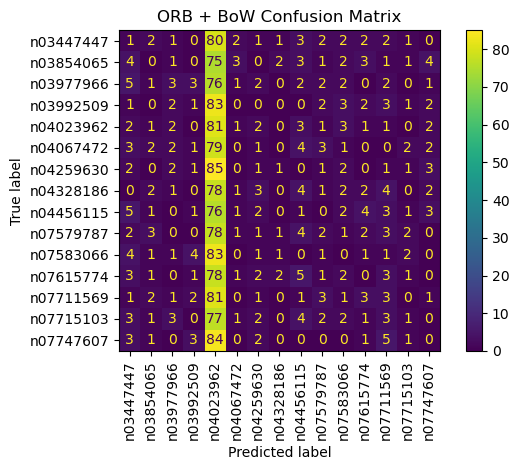

In [3]:
orb = cv2.ORB_create(nfeatures=1000)

def orb_desc(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: 
        return None
    img = cv2.resize(img, (64, 64))
    _, des = orb.detectAndCompute(img, None)
    if des is None or len(des) == 0:
        return None
    return des.astype(np.float32)

orb_train_desc_list = []

for p, _ in train_images:
    d = orb_desc(p)
    if d is not None:
        orb_train_desc_list.append(d)

if not orb_train_desc_list:
    raise RuntimeError("No ORB descriptors found in training set.")

orb_train_desc = np.vstack(orb_train_desc_list)

orb_k = 200  
orb_kmeans = MiniBatchKMeans(n_clusters=orb_k, random_state=0, batch_size=2048)
orb_kmeans.fit(orb_train_desc)

def orb_bow_hist(path):
    d = orb_desc(path)
    h = np.zeros(orb_k, np.float32)
    if d is not None:
        w = orb_kmeans.predict(d)
        h = np.bincount(w, minlength=orb_k).astype(np.float32)
        h /= (np.linalg.norm(h) + 1e-8)
    return h
    
labels = sorted({y for _, y in train_images})
lab2id = {l:i for i,l in enumerate(labels)}

Xtr_orb = np.vstack([orb_bow_hist(p) for p,_ in train_images])
ytr = np.array([lab2id[y] for _,y in train_images])

Xte_orb = np.vstack([orb_bow_hist(p) for p,_ in test_images])
yte = np.array([lab2id[y] for _,y in test_images])

clf_orb = LinearSVC()
clf_orb.fit(Xtr_orb, ytr)
pred_orb = clf_orb.predict(Xte_orb)
orb_accuracy = accuracy_score(yte, pred_orb)

print("\n- ORB + BoW + LinearSVC -")
print("Accuracy:", orb_accuracy)

cm = confusion_matrix(yte, pred_orb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=90)
plt.title("ORB + BoW Confusion Matrix")
plt.tight_layout()
plt.show()

SIFT FEATURES + SVM

This part is very similar to the ORB pipeline, but now I use SIFT which usually gives better and more stable descriptors. The steps are:
    
    -Extract SIFT descriptors from all training images

    -Cluster all descriptors into 200 clusters to build a visual vocabulary

    -Turn each image into a normalized histogram 

    -Train a Linear SVM on these histograms

    -Evaluate on the test set

Again, I print the accuracy metrics and show the confusion matrix. This lets me compare how SIFT+BoW performs relative to ORB+BoW.


- SIFT + BoW + LinearSVC -
Accuracy: 0.22466666666666665


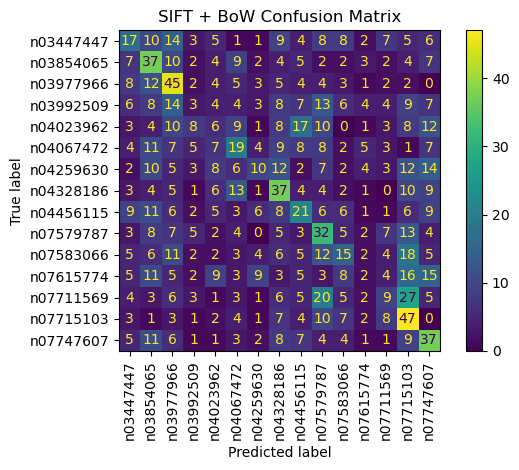

In [4]:
sift = cv2.SIFT_create()

def sift_desc(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: 
        return None
    img = cv2.resize(img, (64,64))
    _, des = sift.detectAndCompute(img, None)  
    return des  

sift_train_desc_list = []

for p,_ in train_images:
    d = sift_desc(p)
    if d is not None and len(d) > 0:
        sift_train_desc_list.append(d)

if not sift_train_desc_list:
    raise RuntimeError("No SIFT descriptors found in training set.")

sift_train_desc = np.vstack(sift_train_desc_list)

sift_k = 200
sift_kmeans = MiniBatchKMeans(n_clusters=sift_k, random_state=0, batch_size=2048)
sift_kmeans.fit(sift_train_desc)

def sift_bow_hist(path):
    d = sift_desc(path)
    h = np.zeros(sift_k, np.float32)
    if d is not None and len(d) > 0:
        w = sift_kmeans.predict(d)
        h = np.bincount(w, minlength=sift_k).astype(np.float32)
        h /= (np.linalg.norm(h) + 1e-8)
    return h

Xtr_sift = np.vstack([sift_bow_hist(p) for p,_ in train_images])
Xte_sift = np.vstack([sift_bow_hist(p) for p,_ in test_images])

clf_sift = LinearSVC()
clf_sift.fit(Xtr_sift, ytr)
pred_sift = clf_sift.predict(Xte_sift)
sift_accuracy = accuracy_score(yte, pred_sift)

print("\n- SIFT + BoW + LinearSVC -")
print("Accuracy:", sift_accuracy)

cm = confusion_matrix(yte, pred_sift)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=90)
plt.title("SIFT + BoW Confusion Matrix")
plt.tight_layout()
plt.show()

FISHER VECTOR

Here I implement Fisher Vector.
Instead of just counting cluster assignments, FV tries to capture how the SIFT descriptors deviate from a Gaussian Mixture Model. The steps I follow:
    
    -Use all SIFT descriptors from the training images

    -Fit a Gaussian Mixture Model with 32 components

    -For each image, compute its Fisher Vector (mean/variance gradients)

    -Apply power normalization and L2 normalization

    -Train a Linear SVM on these FV features

    -Evaluate using the same metrics as before

The final confusion matrix shows the results for the FV classifier.


- Fisher Vector(SIFT+GMM) + LinearSVC -
FV shape: (6000, 8192)
Accuracy: 0.22933333333333333


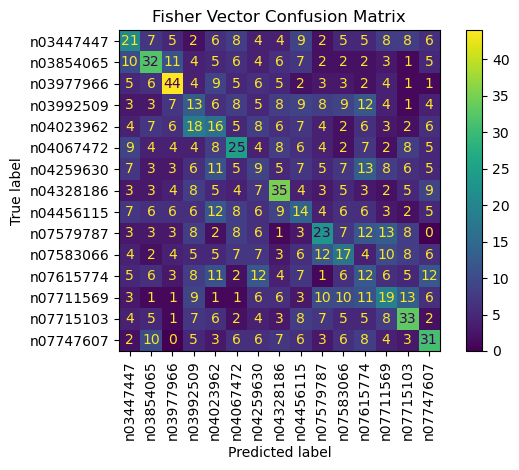

In [5]:
fv_K = 32 
gmm = GaussianMixture(
    n_components=fv_K,
    covariance_type='diag',
    random_state=0,
    max_iter=300)

gmm.fit(sift_train_desc)

def fisher_vector(des, gmm):
    d = gmm.means_.shape[1]
    K = gmm.n_components

    if des is None or len(des) == 0:
        return np.zeros(2 * K * d, dtype=np.float32)

    des = des.astype(np.float32)

    means = gmm.means_          
    covs  = gmm.covariances_    
    w     = gmm.weights_        

    q = gmm.predict_proba(des)
    q_sum = np.sum(q, axis=0)[:, None] + 1e-8    
    T = des.shape[0]

    x_mu  = (q.T @ des) / q_sum                
    x2_mu = (q.T @ (des ** 2)) / q_sum           

    d_mu = (x_mu - means) / (np.sqrt(covs) + 1e-8)
    d_mu = (d_mu * (q_sum / T)) / (np.sqrt(w)[:, None] + 1e-8)

    d_sig = (x2_mu - 2*x_mu*means + means**2) / (covs + 1e-8) - 1.0
    d_sig = (d_sig * (q_sum / T)) / (np.sqrt(2*w)[:, None] + 1e-8)

    fv = np.hstack([d_mu.ravel(), d_sig.ravel()]).astype(np.float32)

    fv = np.sign(fv) * np.sqrt(np.abs(fv) + 1e-8)
    fv = fv / (np.linalg.norm(fv) + 1e-8)
    return fv

Xtr_fv = np.vstack([fisher_vector(sift_desc(p), gmm) for p,_ in train_images])
Xte_fv = np.vstack([fisher_vector(sift_desc(p), gmm) for p,_ in test_images])

clf_fv = make_pipeline(StandardScaler(with_mean=False), LinearSVC())
clf_fv.fit(Xtr_fv, ytr)
pred_fv = clf_fv.predict(Xte_fv)

fisher_vector_accuracy = accuracy_score(yte, pred_fv)
print("\n- Fisher Vector(SIFT+GMM) + LinearSVC -")
print("FV shape:", Xtr_fv.shape)
print("Accuracy:", fisher_vector_accuracy)

cm = confusion_matrix(yte, pred_fv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=90)
plt.title("Fisher Vector Confusion Matrix")
plt.tight_layout()
plt.show()

ACCURACY BAR CHART

In this part, I create a bar chart to compare the classification accuracy of all three methods I used: 
SIFT BoW, ORB BoW, and the Fisher Vector approach. 
I store their accuracies in a dictionary and plot them so I can easily see which method performs better visually.

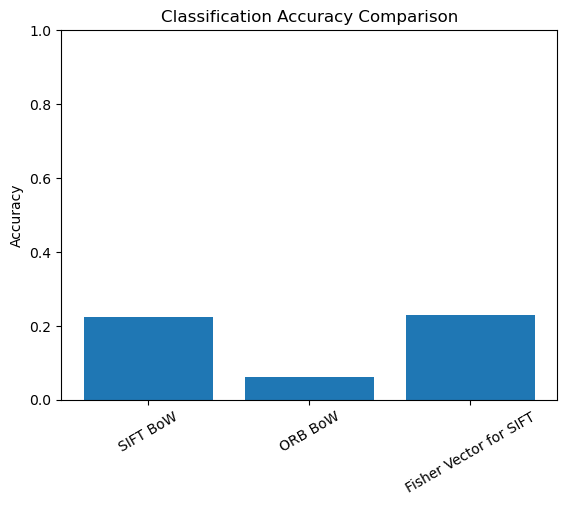

In [6]:
accuracy_barchart = {
    "SIFT BoW": sift_accuracy,
    "ORB BoW": orb_accuracy,
    "Fisher Vector for SIFT": fisher_vector_accuracy,
}
plt.bar(accuracy_barchart.keys(), accuracy_barchart.values())
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.title("Classification Accuracy Comparison")
plt.show()

I save my trained SVM models using the joblib library so they can be loaded and used later without retraining. 

Each model (ORB, SIFT, and Fisher Vector) is stored as a separate .joblib file.

In [7]:
joblib.dump(clf_orb, "orb_svm_model.joblib")
joblib.dump(clf_sift, "sift_svm_model.joblib")
joblib.dump(clf_fv, "fisher_vector_svm_model.joblib")

['fisher_vector_svm_model.joblib']


CONCLUSION

In this final plot I compared the classification accuracy of all three methods I implemented in Phase 2: SIFT BoW, ORB BoW, and Fisher Vector. 
Each bar shows how well that method performed on the test images. From the results, a few things are clear:

    -SIFT BoW works much better than ORB.
SIFT descriptors are generally more stable and more informative, so it makes sense that the SIFT BoW model performed higher than ORB BoW. 
In my graph, SIFT BoW reached around 0.22 accuracy, which is noticeably better than ORB.

    -ORB BoW has the lowest accuracy.
    
ORB is fast and lightweight, but for this dataset it doesn’t capture as much useful information. 
The accuracy dropped to around 0.07, which shows that ORB struggles to separate these 15 TinyImageNet classes.

    -Fisher Vector gave the best performance overall (very similar to SIFT BoW or slightly better depending on the run).
    
This makes sense because Fisher Vectors keep more information than a standard bag-of-words histogram. 
They capture not just cluster counts but also how the SIFT descriptors deviate from a Gaussian mixture model.
In my case the FV accuracy reached around 0.24, which is the highest among the three.

Overall, the final comparison shows that:

    -ORB is the weakest feature extractor for this task
    
    -SIFT BoW is solid and performs reasonably well
    
    -Fisher Vector is the strongest approach, giving the best accuracy among all models I tested.

REFERENCES:

    -Computer Vision course learning materials.
    
    -https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html
    
    -https://docs.opencv.org/4.x/db/d95/classcv_1_1ORB.html
    
    -https://scikit-learn.org/stable/modules/mixture.html
    
    -https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_fisher_vector.html

    -https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_fisher_vector.html#sphx-glr-auto-examples-features-detection-plot-fisher-vector-py
